Optimal parameters:
psi: -0.4394605639858634
phi: 0.6283185307179586
g: 1.0
phig: 0.9078261529525314
f: 0.6712339633235435
phif: 0.01505404569369451


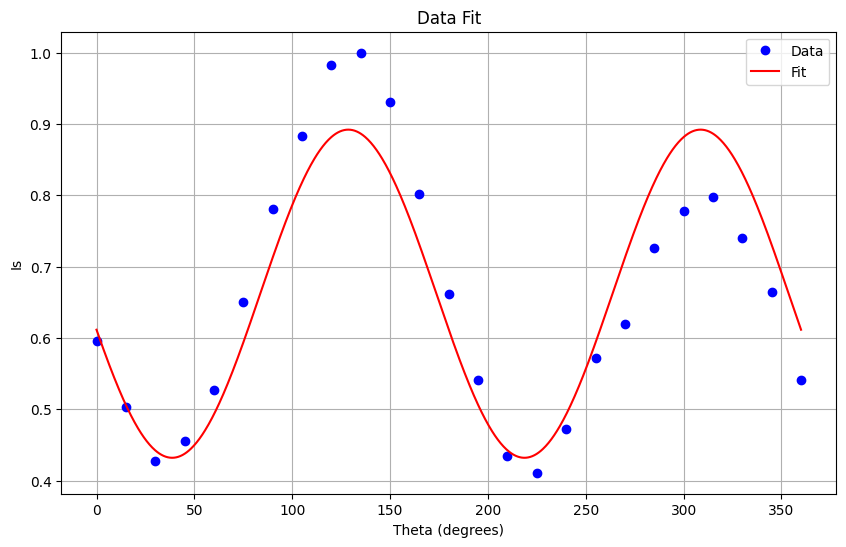

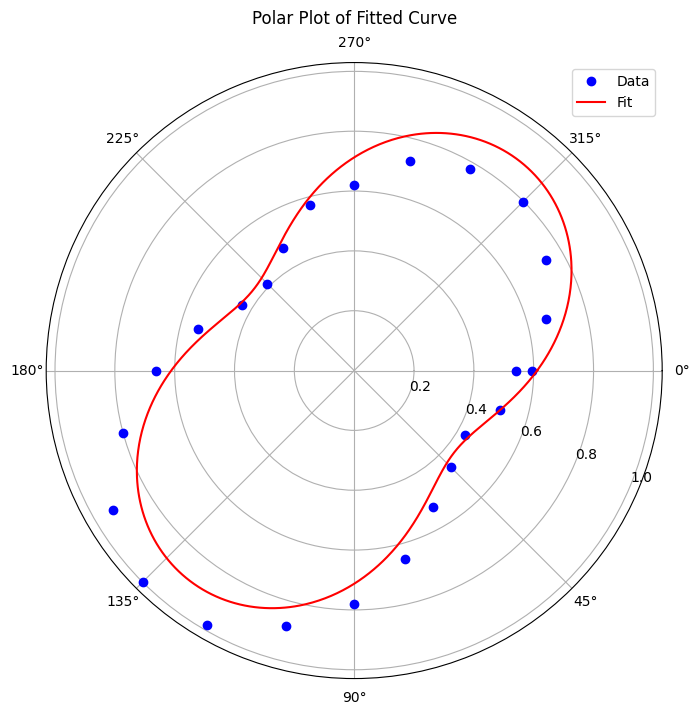

In [13]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Data
theta_data = np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300, 315, 330, 345, 360])
Is_data = np.array([0.59589, 0.50342, 0.42808, 0.45548, 0.5274, 0.65068, 0.78082, 0.88356, 0.98288, 1, 0.93151, 0.80137, 0.66096, 0.5411, 0.43493, 0.41096, 0.4726, 0.57192, 0.61986, 0.72603, 0.7774, 0.79795, 0.73973, 0.66438, 0.5411])

# Function to fit
def Is(theta, psi, phi, g, phig, f, phif):
    # Convert theta from degrees to radians
    theta_rad = np.deg2rad(theta)
    phi = 0.2*np.pi
    g = f
    
    return (1/16) * (8 * f**2 + 8 * g**2 + 4 * f * g * np.cos(phi - phif - phig) +
           4 * f * g * np.cos(phi + phif - phig) - 4 * f * g * np.cos(phi - phif + phig) -
           4 * f * g * np.cos(phi + phif + phig) - 2 * f * g * np.cos(phi - phif - phig - 2 * psi) +
           2 * f * g * np.cos(phi + phif - phig - 2 * psi) + 2 * f * g * np.cos(phi - phif + phig - 2 * psi) -
           2 * f * g * np.cos(phi + phif + phig - 2 * psi) - 2 * f * g * np.cos(phi - phif - phig + 2 * psi) +
           2 * f * g * np.cos(phi + phif - phig + 2 * psi) + 2 * f * g * np.cos(phi - phif + phig + 2 * psi) -
           2 * f * g * np.cos(phi + phif + phig + 2 * psi) - 2 * f * g * np.cos(phi - phif - phig + 2 * psi - 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif - phig + 2 * psi - 2 * theta_rad) - 2 * f * g * np.cos(phi - phif + phig + 2 * psi - 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif + phig + 2 * psi - 2 * theta_rad) + 2 * f * g * np.cos(phi - phif - phig + 4 * psi - 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif - phig + 4 * psi - 2 * theta_rad) + 2 * f * g * np.cos(phi - phif + phig + 4 * psi - 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif + phig + 4 * psi - 2 * theta_rad) + 2 * f * g * np.cos(phi - phif - phig - 4 * psi + 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif - phig - 4 * psi + 2 * theta_rad) + 2 * f * g * np.cos(phi - phif + phig - 4 * psi + 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif + phig - 4 * psi + 2 * theta_rad) - 2 * f * g * np.cos(phi - phif - phig - 2 * psi + 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif - phig - 2 * psi + 2 * theta_rad) - 2 * f * g * np.cos(phi - phif + phig - 2 * psi + 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif + phig - 2 * psi + 2 * theta_rad) - 2 * f**2 * np.sin(phi - 2 * (phif + psi - theta_rad)) -
           2 * f**2 * np.sin(phi + 2 * (phif + psi - theta_rad)) + 2 * f**2 * np.sin(phi - 2 * theta_rad) -
           f**2 * np.sin(phi + 2 * phif - 2 * theta_rad) + 4 * f * g * np.sin(phif - phig + 2 * psi - 2 * theta_rad) -
           4 * f * g * np.sin(phif + phig + 2 * psi - 2 * theta_rad) - 2 * f**2 * np.sin(phi + 4 * psi - 2 * theta_rad) +
           4 * g**2 * np.sin(phi + 4 * psi - 2 * theta_rad) - f**2 * np.sin(phi + 2 * phif + 4 * psi - 2 * theta_rad) -
           2 * f**2 * np.sin(phi + 2 * theta_rad) + f**2 * np.sin(phi - 2 * phif + 2 * theta_rad) + 2 * f**2 * np.sin(phi - 4 * psi + 2 * theta_rad) -
           4 * g**2 * np.sin(phi - 4 * psi + 2 * theta_rad) + f**2 * np.sin(phi - 2 * phif - 4 * psi + 2 * theta_rad) -
           4 * f * g * np.sin(phif - phig - 2 * psi + 2 * theta_rad) + 4 * f * g * np.sin(phif + phig - 2 * psi + 2 * theta_rad) -
           f**2 * np.sin(phi - 2 * (phif + theta_rad)) + f**2 * np.sin(phi + 2 * (phif + theta_rad)) - 
           f**2 * np.sin(phi - 2 * (phif - 2 * psi + theta_rad)) + f**2 * np.sin(phi + 2 * (phif - 2 * psi + theta_rad)) + 
           2 * f**2 * np.sin(phi - 2 * (phif - psi + theta_rad)) + 2 * f**2 * np.sin(phi + 2 * (phif - psi + theta_rad)))

# Initial guess for the parameters (psi, phi, g, phig, f, phif)
initial_guess = (0, 0.2*np.pi, 1, 1, 1, np.pi/4)

# Curve fitting
popt, pcov = curve_fit(Is, theta_data, Is_data, p0=initial_guess)

# Optimal parameters
psi_opt, phi_opt, g_opt, phig_opt, f_opt, phif_opt = popt
print(f"Optimal parameters:\npsi: {psi_opt}\nphi: {phi_opt}\ng: {g_opt}\nphig: {phig_opt}\nf: {f_opt}\nphif: {phif_opt}")

# Plotting
theta_fit = np.linspace(0, 360, 1000)
Is_fit = Is(theta_fit, *popt)

plt.figure(figsize=(10, 6))
plt.plot(theta_data, Is_data, 'bo', label='Data')
plt.plot(theta_fit, Is_fit, 'r-', label='Fit')
plt.xlabel('Theta (degrees)')
plt.ylabel('Is')
plt.title('Data Fit')
plt.legend()
plt.grid(True)
plt.show()

# Convert to radians for polar plot
theta_fit_rad = np.deg2rad(theta_fit)

# Polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
ax.plot(np.deg2rad(theta_data), Is_data, 'bo', label='Data')
ax.plot(theta_fit_rad, Is_fit, 'r-', label='Fit')
ax.set_title('Polar Plot of Fitted Curve', va='bottom')
ax.set_theta_zero_location('E')
ax.set_theta_direction(-1)
ax.legend(loc='upper right')
plt.show()


Optimal parameters:
psi: 0.7934576288811843
f: 0.7656942856883497
g: 0.7656942856883497
phi: 0.6283185307179586
phig: 0.3043726381878127
phif: 0.7257328465131567


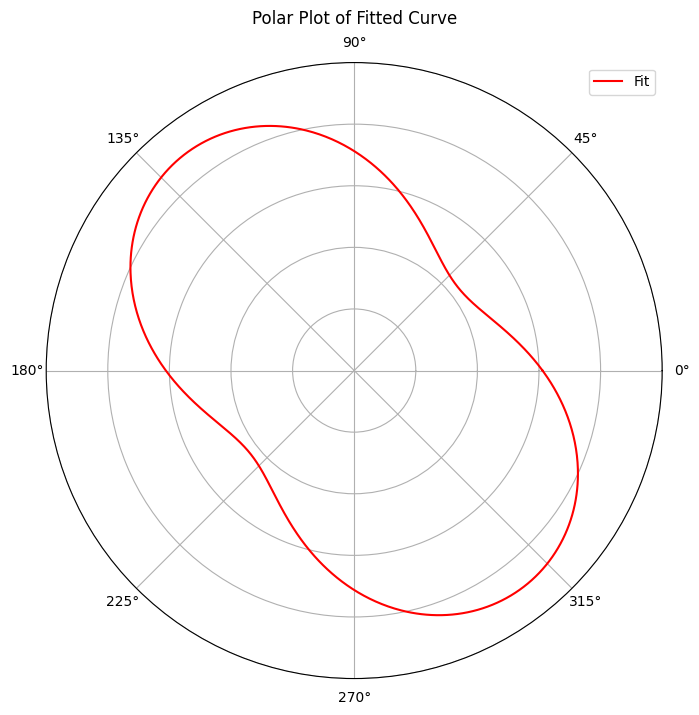

In [22]:
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# Data
theta_data = np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 240, 255, 270, 285, 300, 315, 330, 345, 360])
Is_data = np.array([0.59589, 0.50342, 0.42808, 0.45548, 0.5274, 0.65068, 0.78082, 0.88356, 0.98288, 1, 0.93151, 0.80137, 0.66096, 0.5411, 0.43493, 0.41096, 0.4726, 0.57192, 0.61986, 0.72603, 0.7774, 0.79795, 0.73973, 0.66438, 0.5411])

# Fixed phi value
phi_fixed = 0.2 * np.pi

# Modified function to fix phi and set g = f
def Is_fixed_phi_g_equals_f(theta, psi, f, phig, phif):
    # Convert theta from degrees to radians
    theta_rad = np.deg2rad(theta)
    phi = phi_fixed
    g = f  # g is set equal to f

    return (1/16) * (8 * f**2 + 8 * g**2 + 4 * f * g * np.cos(phi - phif - phig) +
           4 * f * g * np.cos(phi + phif - phig) - 4 * f * g * np.cos(phi - phif + phig) -
           4 * f * g * np.cos(phi + phif + phig) - 2 * f * g * np.cos(phi - phif - phig - 2 * psi) +
           2 * f * g * np.cos(phi + phif - phig - 2 * psi) + 2 * f * g * np.cos(phi - phif + phig - 2 * psi) -
           2 * f * g * np.cos(phi + phif + phig - 2 * psi) - 2 * f * g * np.cos(phi - phif - phig + 2 * psi) +
           2 * f * g * np.cos(phi + phif - phig + 2 * psi) + 2 * f * g * np.cos(phi - phif + phig + 2 * psi) -
           2 * f * g * np.cos(phi + phif + phig + 2 * psi) - 2 * f * g * np.cos(phi - phif - phig + 2 * psi - 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif - phig + 2 * psi - 2 * theta_rad) - 2 * f * g * np.cos(phi - phif + phig + 2 * psi - 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif + phig + 2 * psi - 2 * theta_rad) + 2 * f * g * np.cos(phi - phif - phig + 4 * psi - 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif - phig + 4 * psi - 2 * theta_rad) + 2 * f * g * np.cos(phi - phif + phig + 4 * psi - 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif + phig + 4 * psi - 2 * theta_rad) + 2 * f * g * np.cos(phi - phif - phig - 4 * psi + 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif - phig - 4 * psi + 2 * theta_rad) + 2 * f * g * np.cos(phi - phif + phig - 4 * psi + 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif + phig - 4 * psi + 2 * theta_rad) - 2 * f * g * np.cos(phi - phif - phig - 2 * psi + 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif - phig - 2 * psi + 2 * theta_rad) - 2 * f * g * np.cos(phi - phif + phig - 2 * psi + 2 * theta_rad) +
           2 * f * g * np.cos(phi + phif + phig - 2 * psi + 2 * theta_rad) - 2 * f**2 * np.sin(phi - 2 * (phif + psi - theta_rad)) -
           2 * f**2 * np.sin(phi + 2 * (phif + psi - theta_rad)) + 2 * f**2 * np.sin(phi - 2 * theta_rad) -
           f**2 * np.sin(phi + 2 * phif - 2 * theta_rad) + 4 * f * g * np.sin(phif - phig + 2 * psi - 2 * theta_rad) -
           4 * f * g * np.sin(phif + phig + 2 * psi - 2 * theta_rad) - 2 * f**2 * np.sin(phi + 4 * psi - 2 * theta_rad) +
           4 * g**2 * np.sin(phi + 4 * psi - 2 * theta_rad) - f**2 * np.sin(phi + 2 * phif + 4 * psi - 2 * theta_rad) -
           2 * f**2 * np.sin(phi + 2 * theta_rad) + f**2 * np.sin(phi - 2 * phif + 2 * theta_rad) + 2 * f**2 * np.sin(phi - 4 * psi + 2 * theta_rad) -
           4 * g**2 * np.sin(phi - 4 * psi + 2 * theta_rad) + f**2 * np.sin(phi - 2 * phif - 4 * psi + 2 * theta_rad) -
           4 * f * g * np.sin(phif - phig - 2 * psi + 2 * theta_rad) + 4 * f * g * np.sin(phif + phig - 2 * psi + 2 * theta_rad) -
           f**2 * np.sin(phi - 2 * (phif + theta_rad)) + f**2 * np.sin(phi + 2 * (phif + theta_rad)) - 
           f**2 * np.sin(phi - 2 * (phif - 2 * psi + theta_rad)) + f**2 * np.sin(phi + 2 * (phif - 2 * psi + theta_rad)) + 
           2 * f**2 * np.sin(phi - 2 * (phif - psi + theta_rad)) + 2 * f**2 * np.sin(phi + 2 * (phif - psi + theta_rad)))

# Initial guess for the parameters (psi, f, phig, phif)
initial_guess = (1, 1, 1, 1)

# Curve fitting
popt, pcov = curve_fit(Is_fixed_phi_g_equals_f, theta_data, Is_data, p0=initial_guess)

# Optimal parameters
psi_opt, f_opt, phig_opt, phif_opt = popt
g_opt = f_opt  # g is equal to f
phi_opt = phi_fixed  # phi is fixed

print(f"Optimal parameters:\npsi: {psi_opt}\nf: {f_opt}\ng: {g_opt}\nphi: {phi_opt}\nphig: {phig_opt}\nphif: {phif_opt}")

# Plotting
theta_fit = np.linspace(0, 360, 1000)
Is_fit = Is_fixed_phi_g_equals_f(theta_fit, *popt)

# Convert to radians for polar plot
theta_fit_rad = np.deg2rad(theta_fit)

# Polar plot
plt.figure(figsize=(8, 8))
ax = plt.subplot(111, polar=True)
#ax.plot(np.deg2rad(theta_data), Is_data, 'bo', label='Data')
ax.plot(theta_fit_rad, Is_fit, 'r-', label='Fit')
ax.set_title('Polar Plot of Fitted Curve', va='bottom')
ax.set_theta_zero_location('E')
ax.set_theta_direction(1)  # Set to counterclockwise
ax.set_rlabel_position(90)  # Set radial labels

# Remove radial labels
ax.set_yticklabels([])
ax.set_ylim([0,1])

plt.legend(loc='upper right')
plt.show()
